In [1]:
# ==============================
# 1. IMPORT LIBRARIES
# ==============================
import pandas as pd
import numpy as np
from pathlib import Path

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score, GroupKFold
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression, Ridge, Lasso

import joblib

In [2]:
# ==============================
# 2. LOAD DATA
# ==============================
PROJECT_PATH = Path.cwd().parent
DATA_PATH = PROJECT_PATH / "data" / "train_FD001.csv"

df = pd.read_csv(DATA_PATH)
print("✅ Data loaded — shape:", df.shape)
df.head()

✅ Data loaded — shape: (20631, 27)


,engine_id,cycle,op_setting_1,op_setting_2,op_setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21,RUL
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190,191
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236,190
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442,189
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739,188
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044,187


In [3]:
# ==============================
# 3. VERIFY TARGET (RUL)
# ==============================
assert "RUL" in df.columns, "RUL column missing — run notebook 1 first"
print(df[["engine_id", "cycle", "RUL"]].head())

   engine_id  cycle  RUL
0          1      1  191
1          1      2  190
2          1      3  189
3          1      4  188
4          1      5  187


In [4]:
# ==============================
# 4. RUL CAPPING
# ==============================
RUL_CAP = 125
df["RUL"] = df["RUL"].clip(upper=RUL_CAP)
print(f"✅ RUL capped at {RUL_CAP} — new max:", df["RUL"].max())

✅ RUL capped at 125 — new max: 125


In [5]:
# ==============================
# 5. FEATURE SELECTION
# ==============================
sensor_cols = [col for col in df.columns if col.startswith("sensor")]
op_cols     = [col for col in df.columns if col.startswith("op_setting")]

sensor_variance = df[sensor_cols].std()
low_variance_sensors = sensor_variance[sensor_variance < 0.01].index.tolist()

# op_setting_3 is always 100.0 — constant, drop explicitly
low_variance_ops = [col for col in op_cols if df[col].std() < 0.01]

cols_to_drop = low_variance_sensors + low_variance_ops
print("Dropping low-variance columns:", cols_to_drop)

feature_cols = [
    col for col in df.columns
    if col not in ["engine_id", "cycle", "RUL"] + cols_to_drop
]

print(f"Final feature count: {len(feature_cols)}")
print("Features:", feature_cols)

Dropping low-variance columns: ['sensor_1', 'sensor_5', 'sensor_6', 'sensor_10', 'sensor_16', 'sensor_18', 'sensor_19', 'op_setting_1', 'op_setting_2', 'op_setting_3']
Final feature count: 14
Features: ['sensor_2', 'sensor_3', 'sensor_4', 'sensor_7', 'sensor_8', 'sensor_9', 'sensor_11', 'sensor_12', 'sensor_13', 'sensor_14', 'sensor_15', 'sensor_17', 'sensor_20', 'sensor_21']


In [6]:
# ==============================
# 6. TRAIN-TEST SPLIT (BY ENGINE)
# ==============================
engine_ids = df["engine_id"].unique()

train_engines, test_engines = train_test_split(
    engine_ids, test_size=0.2, random_state=42
)

train_df = df[df["engine_id"].isin(train_engines)].copy()
test_df  = df[df["engine_id"].isin(test_engines)].copy()

X_train = train_df[feature_cols]
y_train = train_df["RUL"]

X_test = test_df[feature_cols]
y_test = test_df["RUL"]

print("Train shape:", X_train.shape)
print("Test shape :", X_test.shape)

Train shape: (16561, 14)
Test shape : (4070, 14)


In [7]:
# ==============================
# 7. LINEAR MODELS (PIPELINE)
# ==============================
linear_models = {
    "Linear": Pipeline([("scaler", StandardScaler()), ("model", LinearRegression())]),
    "Ridge":  Pipeline([("scaler", StandardScaler()), ("model", Ridge())]),
    "Lasso":  Pipeline([("scaler", StandardScaler()), ("model", Lasso())])
}

results = []

for name, model in linear_models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae  = mean_absolute_error(y_test, y_pred)
    r2   = r2_score(y_test, y_pred)

    print(f"\n{name}  →  RMSE: {rmse:.3f}  MAE: {mae:.3f}  R2: {r2:.4f}")
    results.append({"Model": name, "RMSE": rmse, "MAE": mae, "R2": r2})



Linear  →  RMSE: 20.428  MAE: 16.510  R2: 0.7602

Ridge  →  RMSE: 20.428  MAE: 16.510  R2: 0.7602

Lasso  →  RMSE: 20.561  MAE: 16.622  R2: 0.7571


In [8]:
# ==============================
# 8. RANDOM FOREST (BASELINE)
# ==============================
rf = RandomForestRegressor(
    n_estimators=100,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
mae_rf  = mean_absolute_error(y_test, y_pred_rf)
r2_rf   = r2_score(y_test, y_pred_rf)

print(f"\nRandom Forest (baseline)  →  RMSE: {rmse_rf:.3f}  MAE: {mae_rf:.3f}  R2: {r2_rf:.4f}")
results.append({"Model": "Random Forest (baseline)", "RMSE": rmse_rf, "MAE": mae_rf, "R2": r2_rf})



Random Forest (baseline)  →  RMSE: 17.016  MAE: 12.421  R2: 0.8336


In [9]:
# ==============================
# 9. CROSS VALIDATION (GroupKFold)
# ==============================
groups = train_df["engine_id"].values
cv = GroupKFold(n_splits=5)

cv_scores = cross_val_score(
    rf, X_train, y_train,
    scoring="neg_root_mean_squared_error",
    cv=cv,
    groups=groups
)

print(f"\nRandom Forest CV RMSE (GroupKFold): {-cv_scores.mean():.2f} ± {cv_scores.std():.2f}")



Random Forest CV RMSE (GroupKFold): 19.01 ± 1.27


In [10]:
# ==============================
# 10. HYPERPARAMETER TUNING
# ==============================
param_grid = {
    "n_estimators":    [100, 200],
    "max_depth":       [8, 10, 12],
    "min_samples_split": [2, 5]
}

# Must use GroupKFold here too — prevents data leakage across engines
group_cv = list(GroupKFold(n_splits=5).split(X_train, y_train, groups=groups))

grid = GridSearchCV(
    RandomForestRegressor(random_state=42, n_jobs=-1),
    param_grid,
    cv=group_cv,                         # ← pass the splits directly
    scoring="neg_root_mean_squared_error",
    verbose=1,
    n_jobs=-1
)

grid.fit(X_train, y_train)

print("\nBest params:", grid.best_params_)

best_model = grid.best_estimator_
y_pred_final = best_model.predict(X_test)

rmse_final = np.sqrt(mean_squared_error(y_test, y_pred_final))
mae_final  = mean_absolute_error(y_test, y_pred_final)
r2_final   = r2_score(y_test, y_pred_final)

print(f"\nRandom Forest (tuned)  →  RMSE: {rmse_final:.3f}  MAE: {mae_final:.3f}  R2: {r2_final:.4f}")
results.append({"Model": "Random Forest (tuned)", "RMSE": rmse_final, "MAE": mae_final, "R2": r2_final})


Fitting 5 folds for each of 12 candidates, totalling 60 fits

Best params: {'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 200}

Random Forest (tuned)  →  RMSE: 16.999  MAE: 12.400  R2: 0.8339


In [11]:
# ==============================
# 11. MODEL COMPARISON
# ==============================
results_df = pd.DataFrame(results).sort_values("RMSE").reset_index(drop=True)
print("\nModel Comparison:")
print(results_df)


Model Comparison:
                      Model       RMSE        MAE        R2
0     Random Forest (tuned)  16.999295  12.400163  0.833941
1  Random Forest (baseline)  17.015822  12.420933  0.833617
2                    Linear  20.428188  16.509638  0.760193
3                     Ridge  20.428223  16.509656  0.760192
4                     Lasso  20.560987  16.621607  0.757065


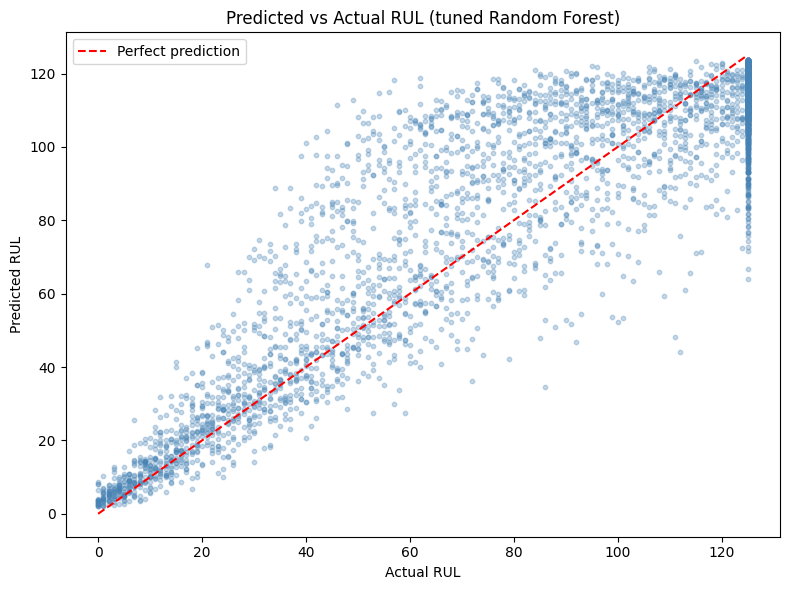

In [12]:
# ==============================
# 12. PREDICTED vs ACTUAL PLOT  ← new
# ==============================
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_final, alpha=0.3, s=10, color="steelblue")
plt.plot([0, RUL_CAP], [0, RUL_CAP], "r--", linewidth=1.5, label="Perfect prediction")
plt.xlabel("Actual RUL")
plt.ylabel("Predicted RUL")
plt.title("Predicted vs Actual RUL (tuned Random Forest)")
plt.legend()
plt.tight_layout()
plt.show()

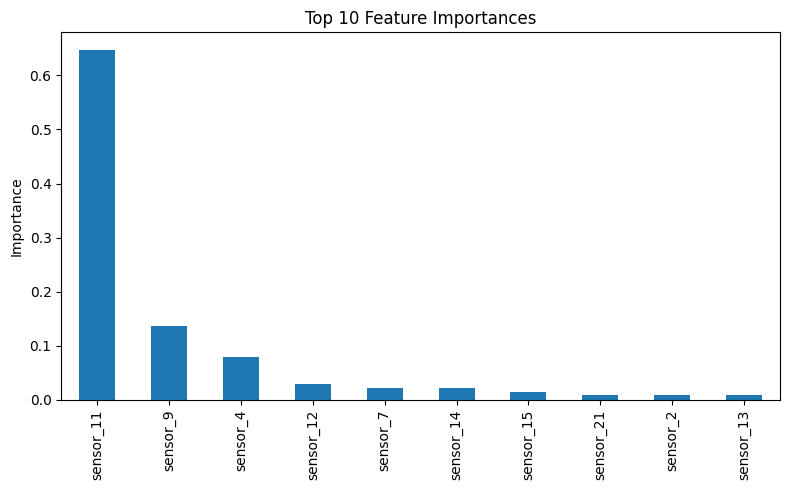

In [13]:
# ==============================
# 13. FEATURE IMPORTANCE
# ==============================
importances = pd.Series(
    best_model.feature_importances_,
    index=feature_cols
).sort_values(ascending=False)

plt.figure(figsize=(8, 5))
importances.head(10).plot(kind="bar")
plt.title("Top 10 Feature Importances")
plt.ylabel("Importance")
plt.tight_layout()
plt.show()

In [14]:
# ==============================
# 14. SAVE MODEL
# ==============================
MODEL_PATH = PROJECT_PATH / "models"
MODEL_PATH.mkdir(exist_ok=True)

joblib.dump(best_model, MODEL_PATH / "rf_rul_model.pkl")
joblib.dump(feature_cols, MODEL_PATH / "feature_columns.pkl")

print("✅ Model saved to:", MODEL_PATH / "rf_rul_model.pkl")
print("✅ Features saved to:", MODEL_PATH / "feature_columns.pkl")

✅ Model saved to: c:\Users\venut\OneDrive\Documents\Projects\predictive_maintenance\models\rf_rul_model.pkl
✅ Features saved to: c:\Users\venut\OneDrive\Documents\Projects\predictive_maintenance\models\feature_columns.pkl
